In [1]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

In [2]:
water_engineered_path = PATHS['engineered_data'] / 'water_engineered.parquet'
df = pd.read_parquet(water_engineered_path)
df.head()

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w
0,1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN
1,1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0
2,1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0
3,1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0
4,1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


MAE: 22.21


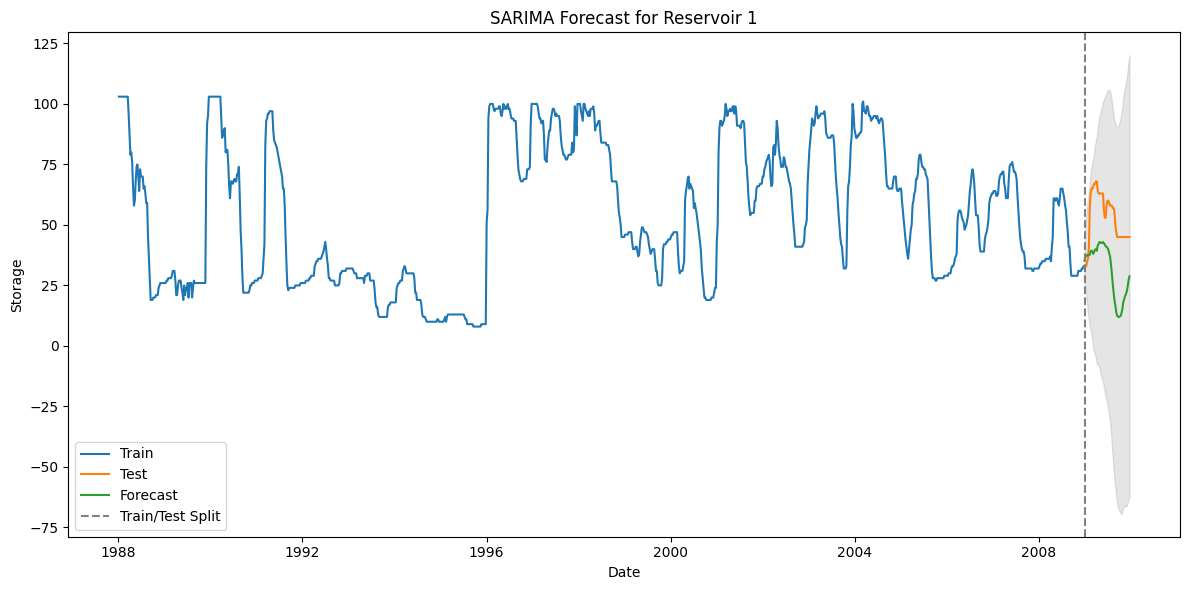

In [5]:
reservoir_id = 1
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[:-52]
test = series.iloc[-52:]

# Fit SARIMA (seasonal order for weekly data: s=52)
# You can tune (p,d,q) and (P,D,Q) or use auto_arima for automation
order = (1,1,1)
seasonal_order = (1,1,1,52)
model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Forecast next 52 weeks
forecast = results.get_forecast(steps=52)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Evaluation
mae = mean_absolute_error(test, forecast_mean)
print(f'MAE: {mae:.2f}')

# Plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='gray', alpha=0.2)
plt.axvline(test.index[0], color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title(f'SARIMA Forecast for Reservoir {reservoir_id}')
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

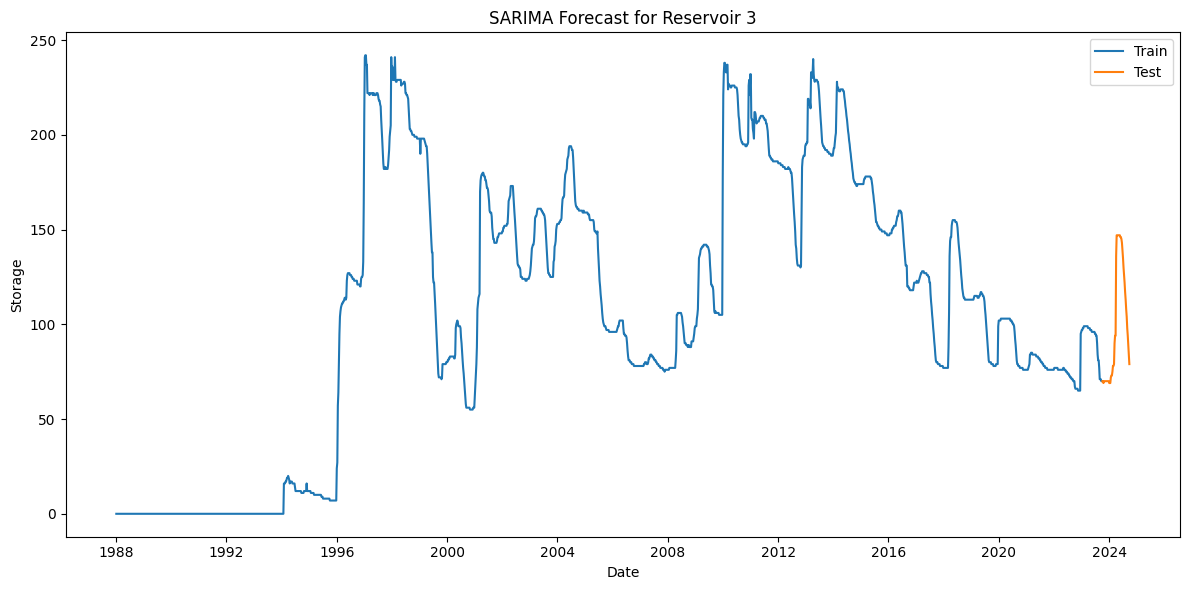

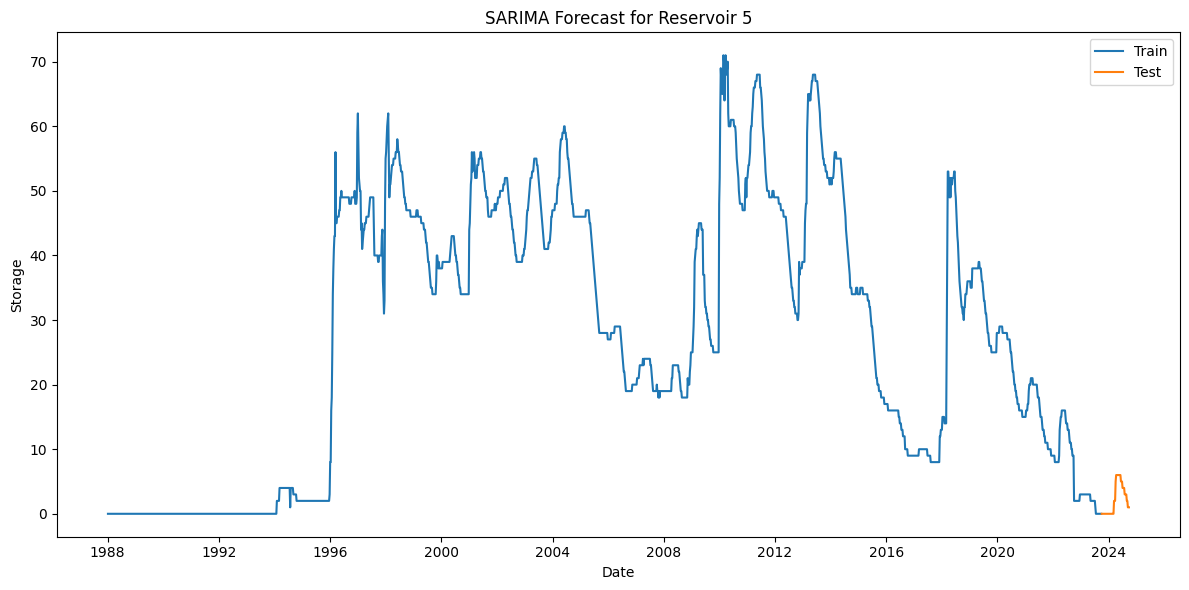

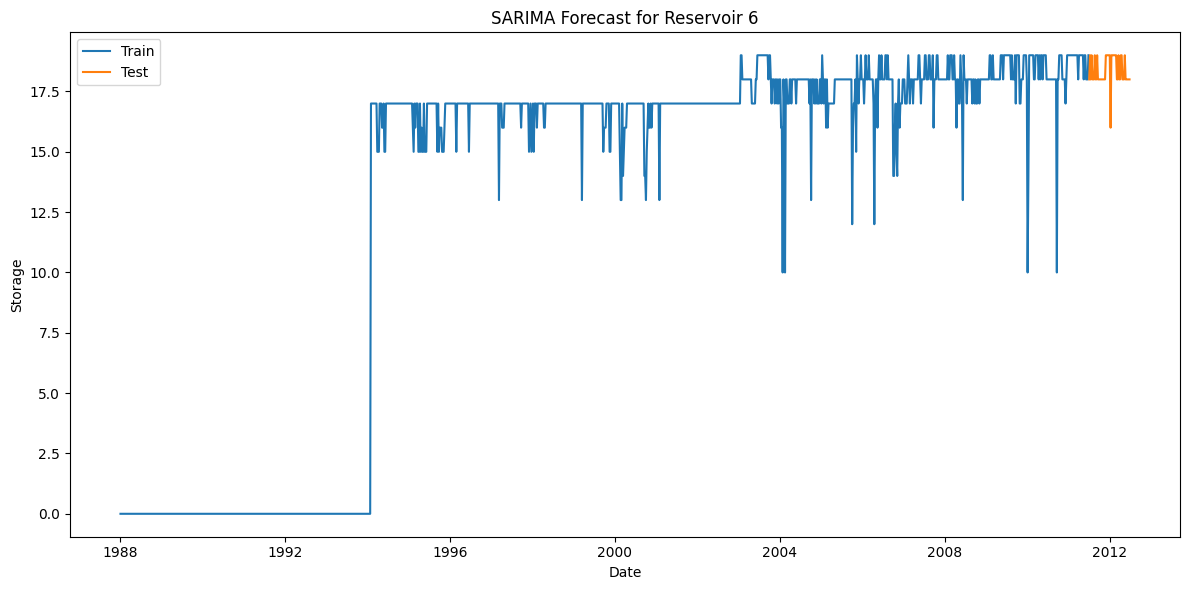

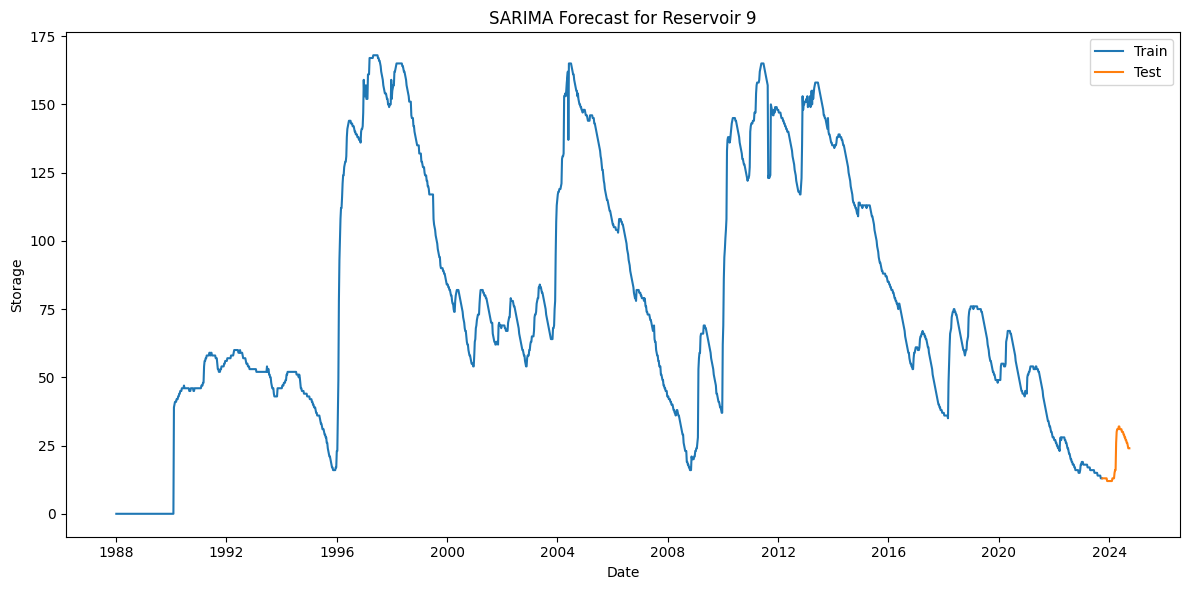

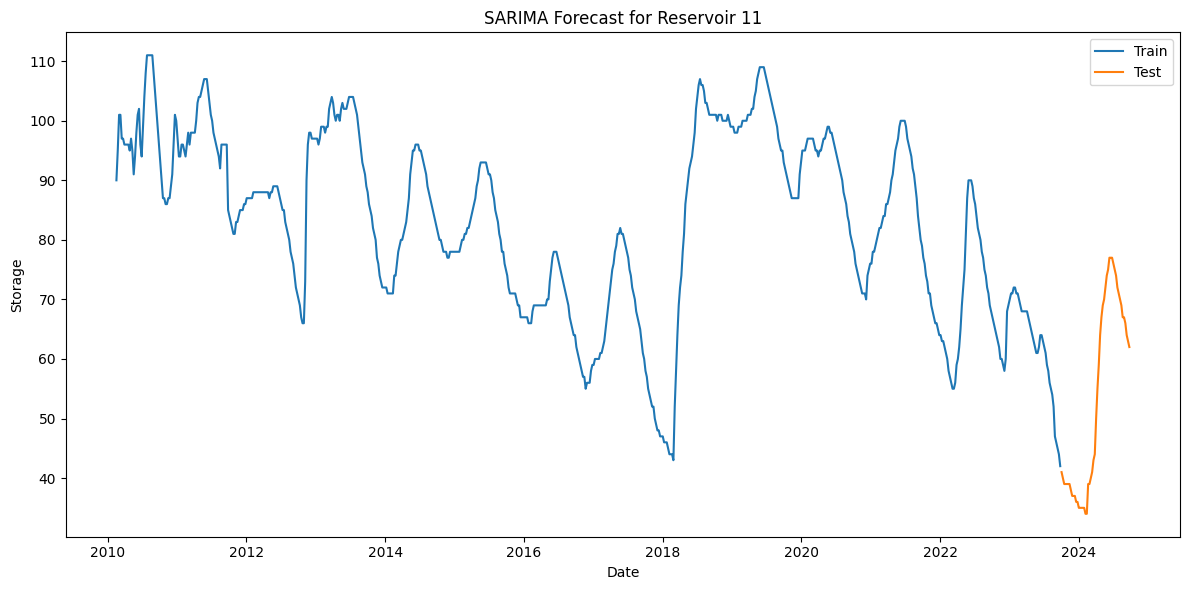

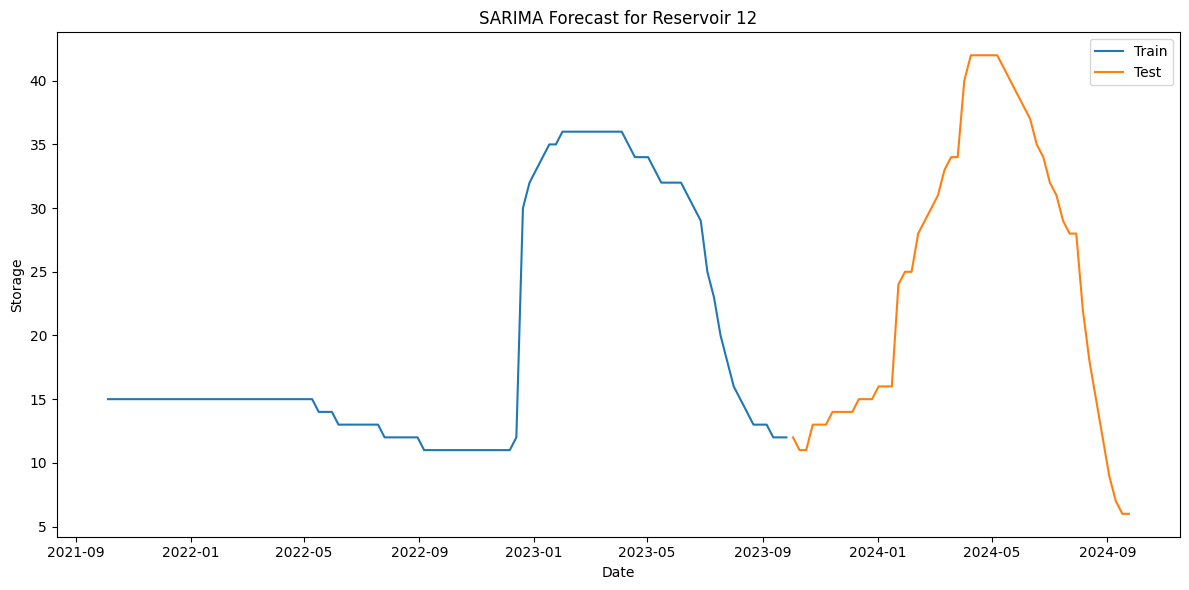

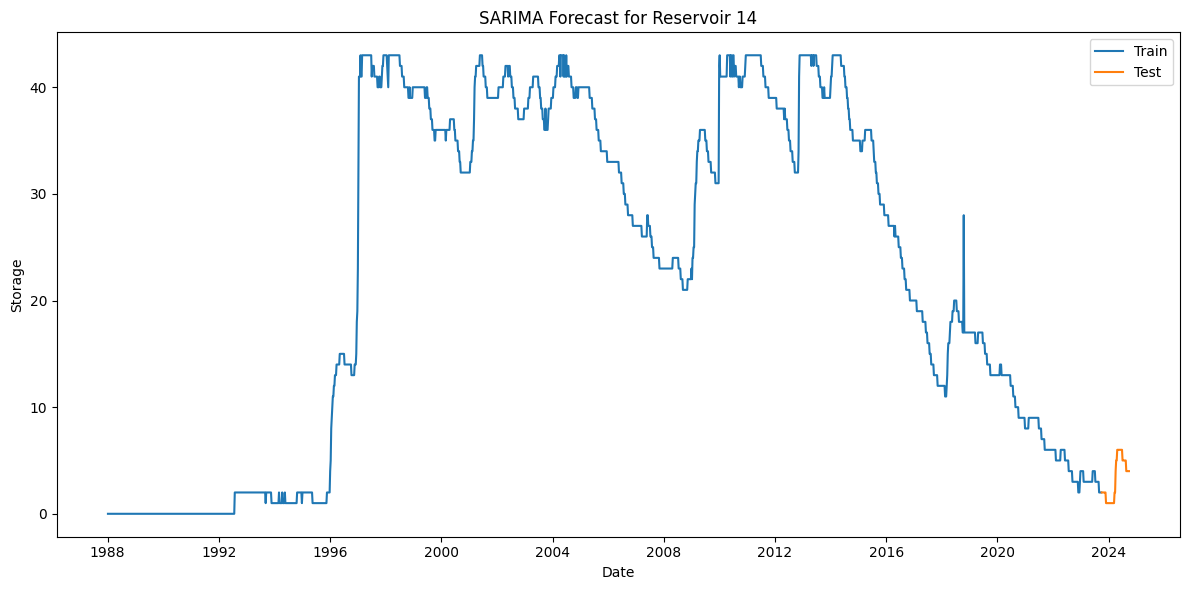

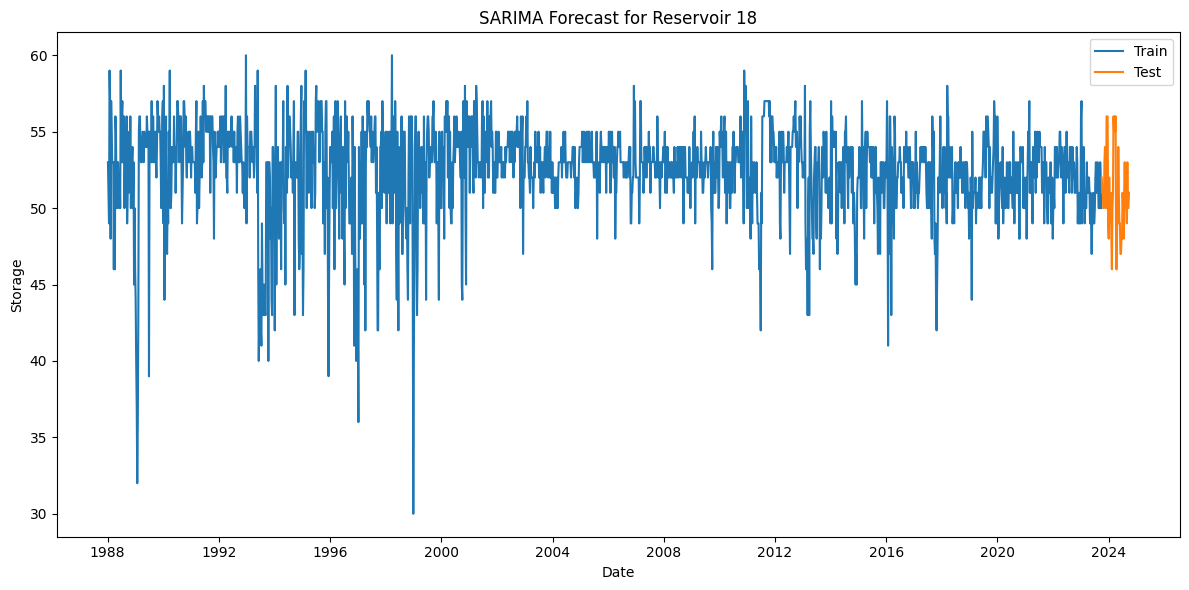

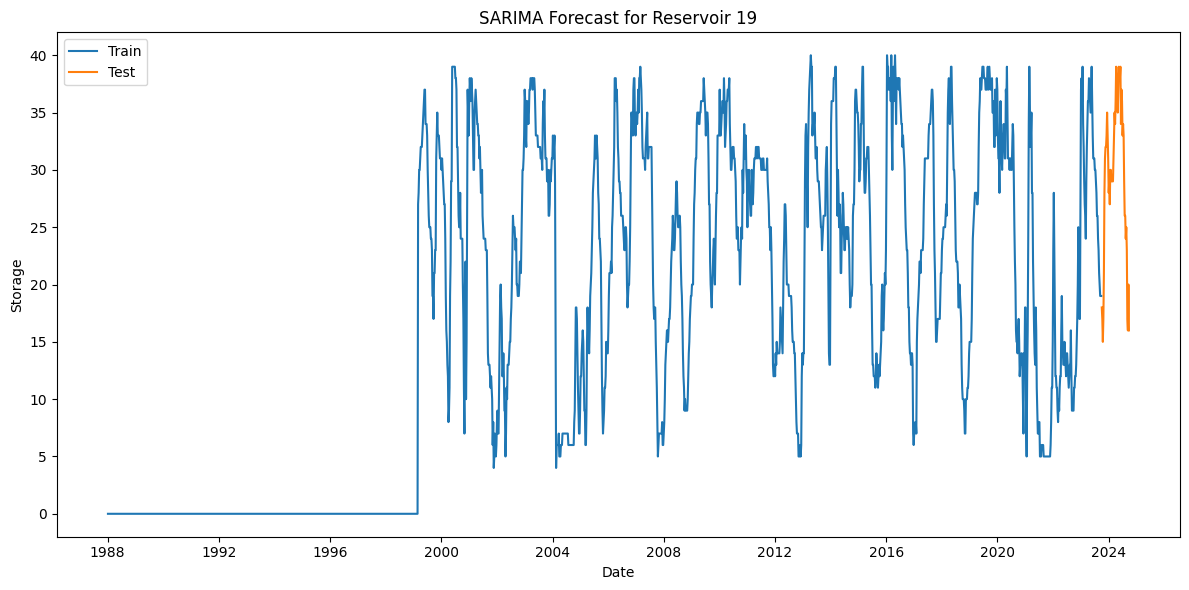

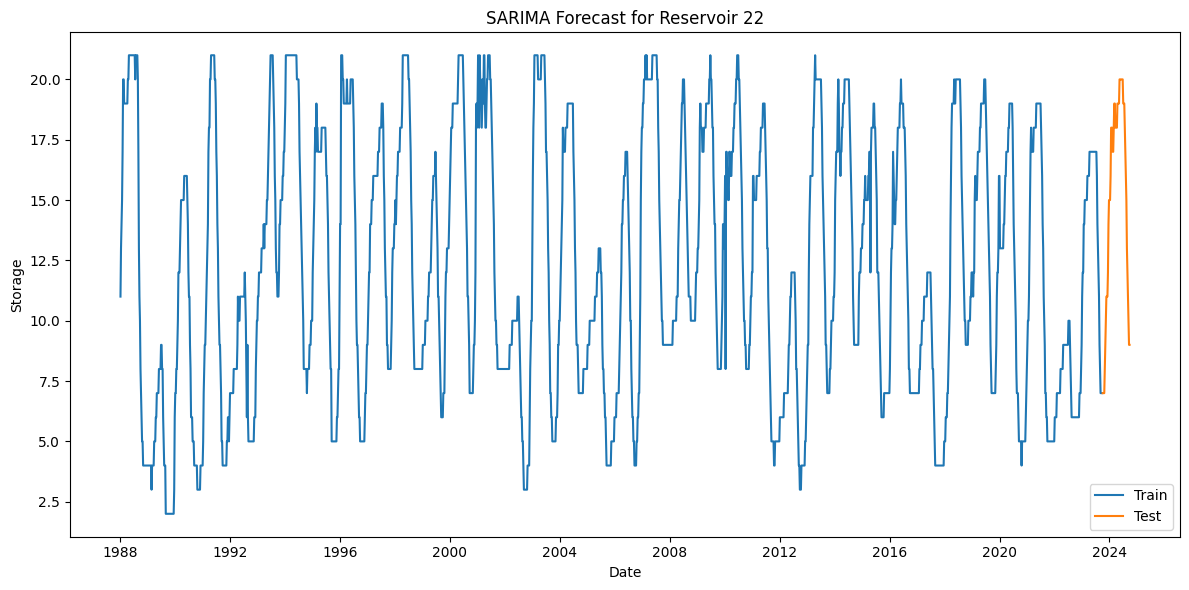

In [10]:
for reservoir_id in df['id'].unique()[1:11]:
    df_res = df[df['id'] == reservoir_id].copy()
    df_res = df_res.sort_values('date')

        # Set date as index
    series = df_res.set_index('date')['storage']

    # Train/test split: last 52 weeks as test
    train = series.iloc[:-52]
    test = series.iloc[-52:]

    plt.figure(figsize=(12,6))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.legend()
    plt.title(f'SARIMA Forecast for Reservoir {reservoir_id}')
    plt.xlabel('Date')
    plt.ylabel('Storage')
    plt.tight_layout()
    plt.show()

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


MAE: 12.43


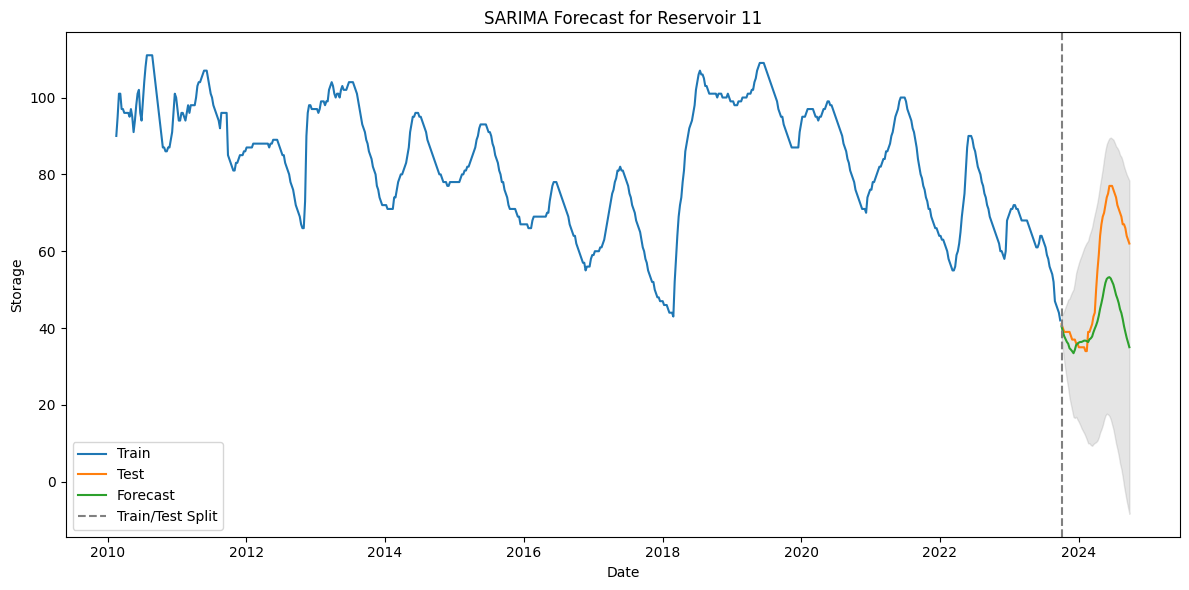

In [7]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[:-52]
test = series.iloc[-52:]

# Fit SARIMA (seasonal order for weekly data: s=52)
# You can tune (p,d,q) and (P,D,Q) or use auto_arima for automation
order = (1,1,1)
seasonal_order = (1,1,1,52)
model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Forecast next 52 weeks
forecast = results.get_forecast(steps=52)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Evaluation
mae = mean_absolute_error(test, forecast_mean)
print(f'MAE: {mae:.2f}')

# Plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='gray', alpha=0.2)
plt.axvline(test.index[0], color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title(f'SARIMA Forecast for Reservoir {reservoir_id}')
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

In [3]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[:-52]
test = series.iloc[-52:]

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


mae: 12.4275
mse: 267.5524
mape: 0.1939


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


mae: 12.4275
mse: 267.5524
mape: 0.1939


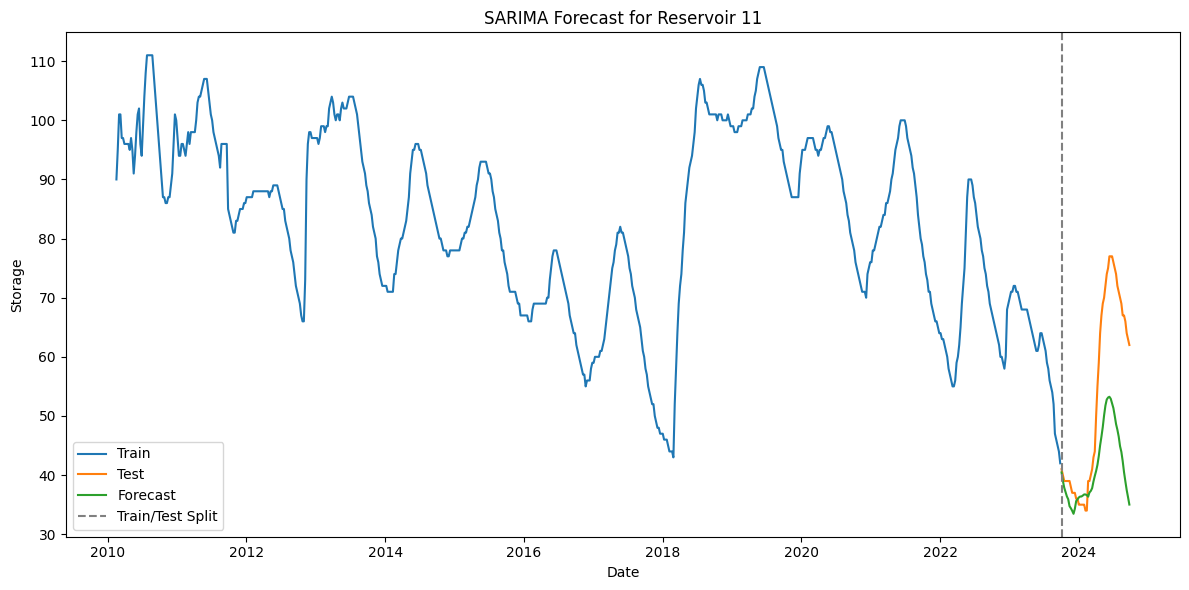

In [6]:
from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast)
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


mae: 13.8485
mse: 336.4978
mape: 0.2165


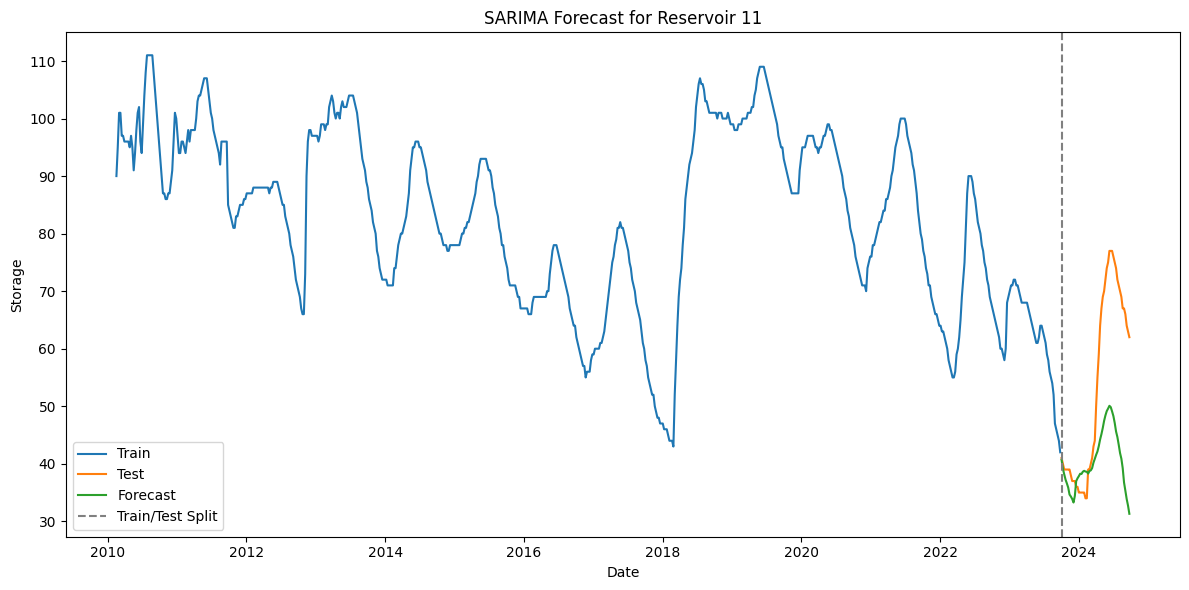

In [8]:
from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(4,1,2), seasonal_order=(1,1,2,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast) # Make an argument as plot_results = True
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

mae: 13.8485
mse: 336.4978
mape: 0.2165


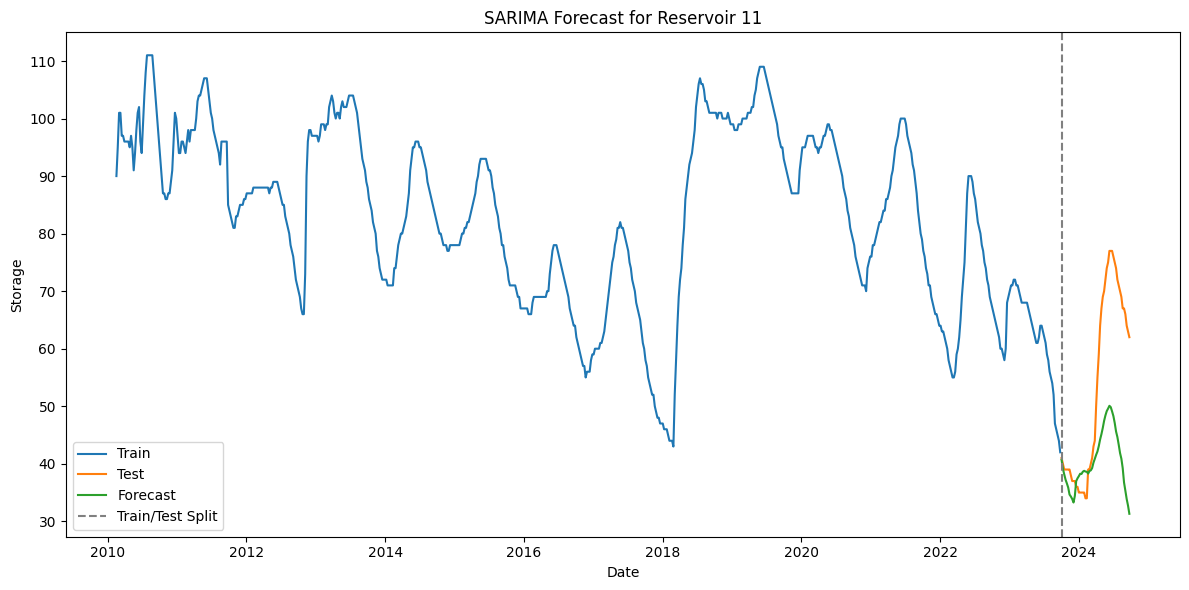

In [11]:
forecast = model.predict(steps=52)

results = model.evaluate(test, forecast) # Make an argument as plot_results = True
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)


mae: 6.6278
mse: 57.8880
mape: 0.2116


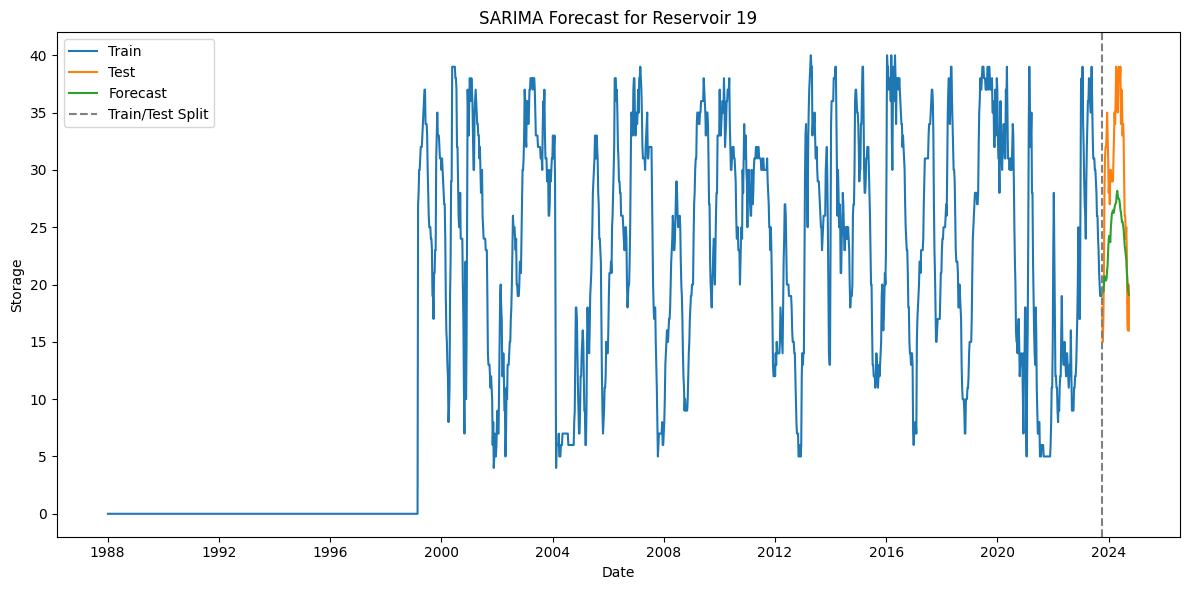

In [12]:
reservoir_id = 19
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[:-52]
test = series.iloc[-52:]

from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast)
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


mae: 6.3468
mse: 57.1241
mape: 0.2403


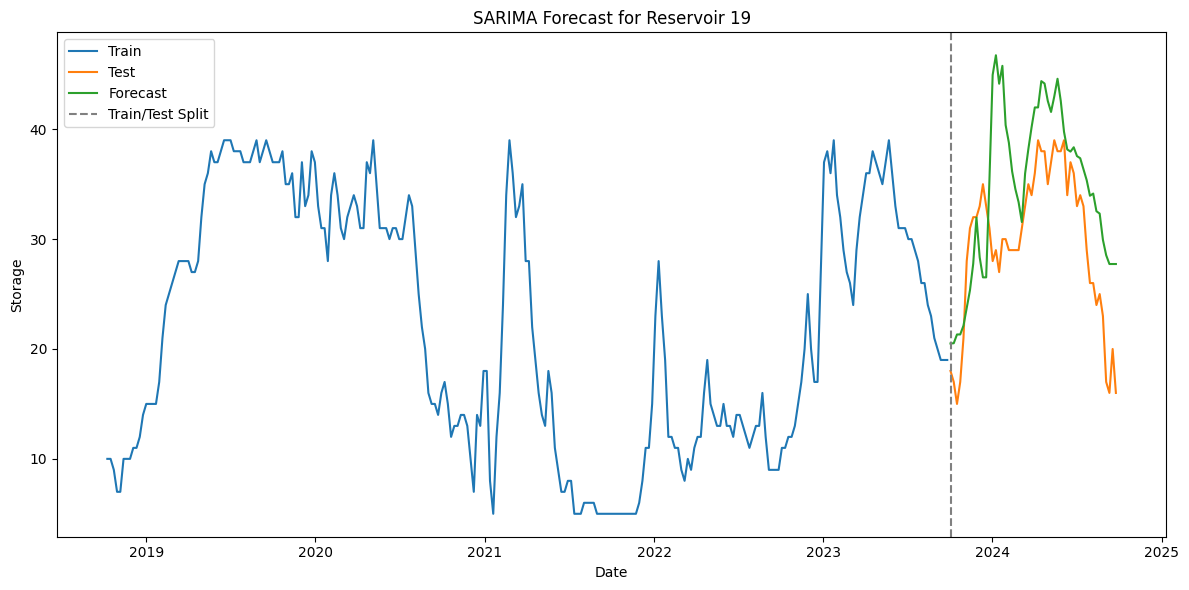

In [13]:
reservoir_id = 19
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52*6):-52]
test = series.iloc[-52:]

from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast)
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


mae: 17.8938
mse: 416.1144
mape: 0.3223
mae: 17.8938
mse: 416.1144
mape: 0.3223


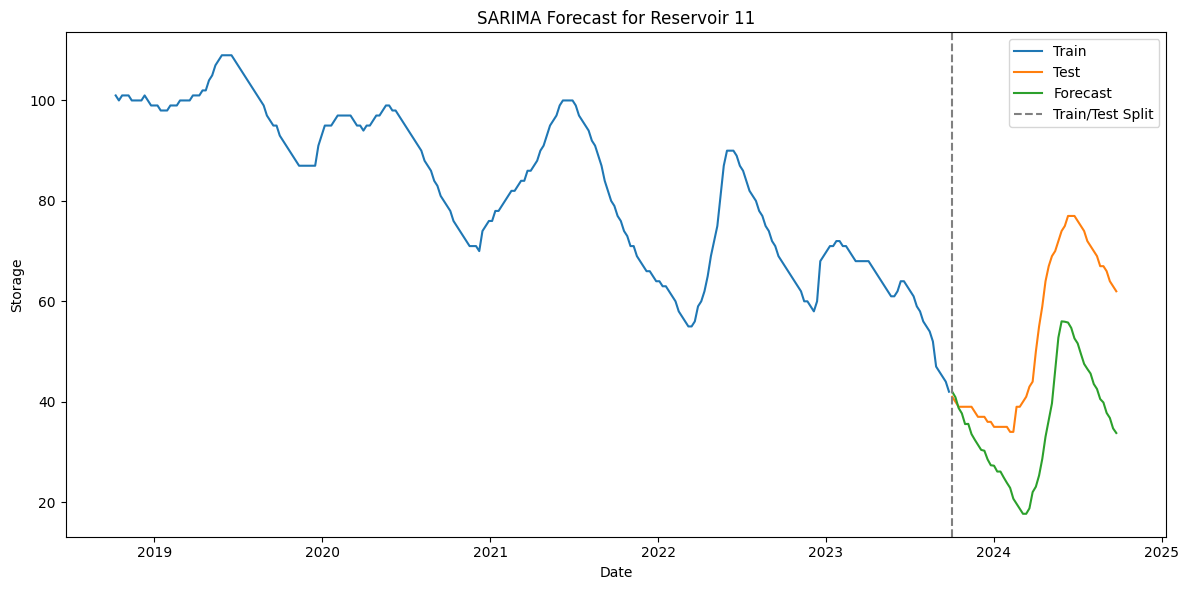

In [3]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52*6):-52]
test = series.iloc[-52:]

from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast)


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-TUE will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


mae: 0.8521
mse: 1.3050
mape: 168353544053072.8438
mae: 0.8521
mse: 1.3050
mape: 168353544053072.8438


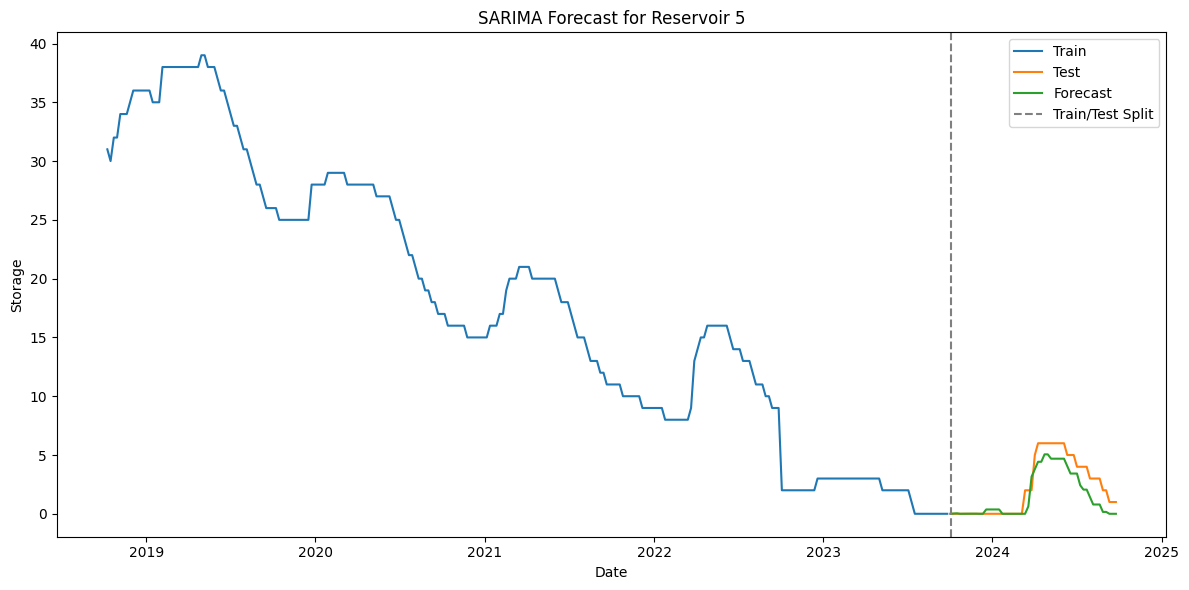

In [3]:
reservoir_id = 5
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52*6):-52]
test = series.iloc[-52:]

from backend.modeling.sarima_model import SARIMAModel
# Instantiate and fit SARIMAModel
model = SARIMAModel(order=(1,1,1), seasonal_order=(1,1,1,52))
model.fit(train)

forecast = model.predict(steps=52)

results = model.evaluate(test, forecast)
for key, value in results.items():
    print(f"{key}: {value:.4f}")


# Plot using the interface method
model.plot_prediction(train, test, forecast, reservoir_id)

In [5]:
print(forecast)

2023-10-03    0.000000
2023-10-10    0.024258
2023-10-17    0.038103
2023-10-24   -0.585926
2023-10-31   -0.581416
2023-11-07   -0.578842
2023-11-14   -0.577373
2023-11-21   -0.576534
2023-11-28   -0.576055
2023-12-05   -1.207713
2023-12-12   -1.207557
2023-12-19   -0.839399
2023-12-26   -0.839348
2024-01-02   -0.839319
2024-01-09   -0.839303
2024-01-16   -0.839293
2024-01-23   -1.471219
2024-01-30   -1.471215
2024-02-06   -1.471214
2024-02-13   -1.471213
2024-02-20   -1.471212
2024-02-27   -1.471212
2024-03-05   -1.471212
2024-03-12   -1.471212
2024-03-19   -0.839281
2024-03-26    1.688442
2024-04-02    2.320373
2024-04-09    2.952304
2024-04-16    2.952304
2024-04-23    3.584235
2024-04-30    3.584235
2024-05-07    3.216166
2024-05-14    3.216166
2024-05-21    3.216166
2024-05-28    3.216166
2024-06-04    3.216166
2024-06-11    2.584235
2024-06-18    1.952304
2024-06-25    1.952304
2024-07-02    1.952304
2024-07-09    0.952304
2024-07-16    0.584235
2024-07-23    0.584235
2024-07-30 